# NHANES — results

## Selector ranking (GB + LogReg, no SVM)

Values are mean **AUC** and **AP** over **k ∈ {5,10,20,40}**. **Overall** aggregates both models; **(GB)** and **(LogReg)** restrict to one model. Sorted by **Overall Mean AP**.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

repo = Path.cwd().parent
sys.path.append(str(repo))

import matplotlib.pyplot as plt
import pandas as pd

In [2]:
results_dir = repo / "results" / "2026-05-03_23-48-47_nhanes"
metrics_path = results_dir / "metrics_nhanes.csv"
metrics_per_fold_path = results_dir / "metrics_nhanes_per_fold.csv"

df = pd.read_csv(metrics_path)

In [3]:
baseline_sels = ["correlation", "l1", "rfe", "shap"]
mi_sels = ["mi", "mrmr_heuristic", "cmim", "jmi", "pid"]
type_map = {s: "baseline" for s in baseline_sels} | {s: "MI-based" for s in mi_sels}
selector_display = {
    "correlation": "Correlation",
    "l1": "L1",
    "rfe": "RFE",
    "shap": "SHAP",
    "mi": "MI",
    "mrmr_heuristic": "mRMR",
    "cmim": "CMIM",
    "jmi": "JMI",
    "pid": "PID",
}
models = ["gradient_boosting", "logreg"]
ks = [5, 10, 20, 40]

sub = df.loc[
    df["model"].isin(models) & df["k"].isin(ks)
]
overall = sub.groupby("selector", as_index=False).agg(
    **{
        "Overall Mean AUC": ("auc_mean", "mean"),
        "Overall Mean AP": ("avg_precision_mean", "mean"),
    }
)
gb = (
    sub.loc[sub["model"] == "gradient_boosting"]
    .groupby("selector", as_index=False)
    .agg(**{"Mean AUC (GB)": ("auc_mean", "mean"), "Mean AP (GB)": ("avg_precision_mean", "mean")})
)
lr = (
    sub.loc[sub["model"] == "logreg"]
    .groupby("selector", as_index=False)
    .agg(
        **{
            "Mean AUC (LogReg)": ("auc_mean", "mean"),
            "Mean AP (LogReg)": ("avg_precision_mean", "mean"),
        }
    )
)
ranking = overall.merge(gb, on="selector").merge(lr, on="selector").rename(columns={"selector": "Selector"})
ranking["Type"] = ranking["Selector"].map(type_map)
num = [
    "Mean AUC (GB)",
    "Mean AP (GB)",
    "Mean AUC (LogReg)",
    "Mean AP (LogReg)",
    "Overall Mean AUC",
    "Overall Mean AP",
]
ranking[num] = ranking[num].round(3)
cols = ["Selector", "Type", *num]
ranking = ranking.sort_values("Overall Mean AP", ascending=False, ignore_index=True)
ranking[cols]


,Selector,Type,Mean AUC (GB),Mean AP (GB),Mean AUC (LogReg),Mean AP (LogReg),Overall Mean AUC,Overall Mean AP
0,rfe,baseline,0.882,0.354,0.881,0.361,0.882,0.358
1,pid,MI-based,0.876,0.344,0.876,0.343,0.876,0.344
2,shap,baseline,0.877,0.339,0.877,0.342,0.877,0.341
3,cmim,MI-based,0.879,0.340,0.877,0.339,0.878,0.340
4,jmi,MI-based,0.876,0.336,0.876,0.337,0.876,0.336
5,mi,MI-based,0.873,0.327,0.872,0.330,0.873,0.329
6,correlation,baseline,0.873,0.323,0.872,0.330,0.873,0.327
7,l1,baseline,0.870,0.327,0.869,0.326,0.869,0.326
8,mrmr_heuristic,MI-based,0.861,0.297,0.860,0.289,0.860,0.293


## LogReg average precision vs **k** Plots (left: classical, right: MI-based)

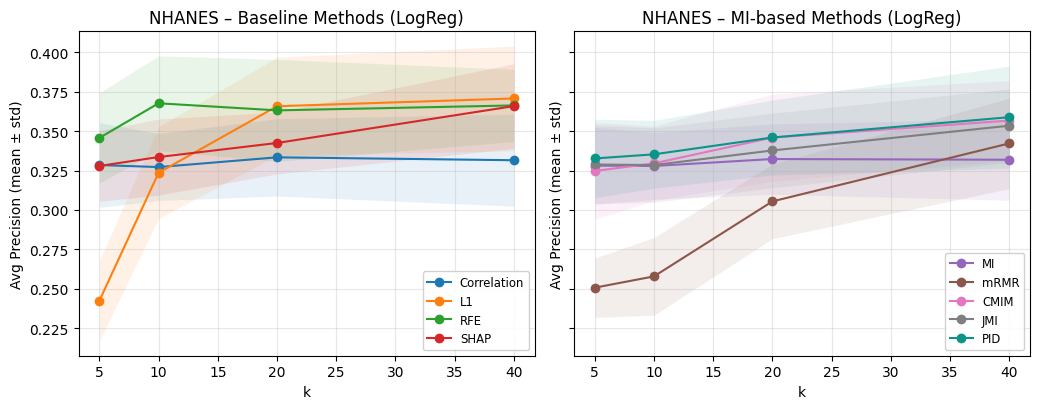

In [4]:
from src.analysis.plotting import plot_metric_two_selector_groups

df_lr = df.loc[df["model"] == "logreg"]

_ = plot_metric_two_selector_groups(
    df_lr,
    metric="avg_precision",
    selectors_left=["correlation", "l1", "rfe", "shap"],
    selectors_right=["mi", "mrmr_heuristic", "cmim", "jmi", "pid"],
    title_left="NHANES \u2013 Baseline Methods (LogReg)",
    title_right="NHANES \u2013 MI-based Methods (LogReg)",
    selector_labels=selector_display,
    save_path=results_dir / "avg_precision_logreg_nhanes.png",
)

### Takeaways

- **Classical selectors:** $\ell_1$-based picks are weak at **k=5** but improve sharply as more nonzero coefficients surface; **RFE / SHAP** reach the strongest average precision among this group once **k** is moderately large (**20–40**). **Correlation** is stable across **k**, sitting near the middling $\approx 0.33$ band.
- **MI-based selectors:** naive **MI** margins are roughly flat versus **k** and similar to **correlation**. **CMIM**, **PID**, and **JMI** trend upward with **k**, with **PID** and **CMIM** among the best MI-conditioned curves at larger **k**. **mRMR (heuristic)** is low at small **k** but catches up noticeably by **k=40**, reflecting its dependence on a broader redundant set.
- **Cross-panel read:** the shared vertical scale emphasizes that the top classical curves at **k ≥ 20** (**RFE/SHAP**) and the strongest MI conditioners (**CMIM**, **PID**, **JMI**) occupy a similar high band.

## Top selectors (same 4 lines): gradient boosting vs logistic regression

Top 2 baselines + top 2 MI-based by **overall mean avg precision** (GB + LogReg, k ∈ {5, 10, 20, 40}), matching the ranking table above.


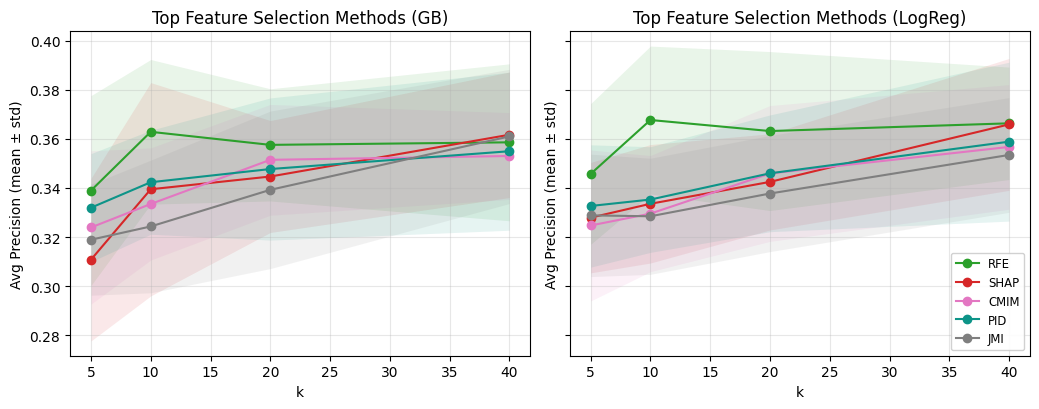

In [5]:
from src.analysis.plotting import plot_metric_two_models_same_selectors

overall_ap = (
    df.loc[df["model"].isin(models) & df["k"].isin(ks)]
    .groupby("selector")["avg_precision_mean"]
    .mean()
)
# top4 = (
#     overall_ap.loc[overall_ap.index.intersection(baseline_sels)].nlargest(2).index.tolist()
#     + overall_ap.loc[overall_ap.index.intersection(mi_sels)].nlargest(2).index.tolist()
# )

best_baselines = ["rfe", "shap"]
best_mi_based = ["cmim", "pid", "jmi"]

fig_top = plot_metric_two_models_same_selectors(
    df,
    metric="avg_precision",
    selectors=best_baselines + best_mi_based,
    model_left="gradient_boosting",
    model_right="logreg",
    title_left="Top Feature Selection Methods (GB)",
    title_right="Top Feature Selection Methods (LogReg)",
    selector_labels=selector_display,
    save_path=results_dir / "top_selectors_gb_logreg_avg_precision.png",
)
legend_r = fig_top.axes[0].get_legend()
if legend_r is not None:
    legend_r.remove()

## Selected-feature stability on NHANES

In [6]:
from src.analysis.stability import compute_stability_table

df_nhanes_per_fold = pd.read_csv(metrics_per_fold_path)

stability_df_k5 = compute_stability_table(df_nhanes_per_fold, model="logreg", k=5)
display(stability_df_k5)

stability_df_k10 = compute_stability_table(df_nhanes_per_fold, model="logreg", k=10)
display(stability_df_k10)

stability_df_k20 = compute_stability_table(df_nhanes_per_fold, model="logreg", k=20)
display(stability_df_k20)

stability_df_k40 = compute_stability_table(df_nhanes_per_fold, model="logreg", k=40)
display(stability_df_k40)


,Selector,Mean Jacc. Sim. (k=5),Num folds
0,correlation,1.000000,5
1,jmi,0.742857,5
2,shap,0.733333,5
3,cmim,0.700000,5
4,l1,0.638095,5
5,mi,0.595238,5
6,mrmr_heuristic,0.482143,5
7,pid,0.416667,5
8,rfe,0.380952,5


,Selector,Mean Jacc. Sim. (k=10),Num folds
0,correlation,0.927273,5
1,shap,0.857576,5
2,jmi,0.806061,5
3,cmim,0.719814,5
4,mi,0.668998,5
5,rfe,0.615385,5
6,l1,0.595738,5
7,mrmr_heuristic,0.401465,5
8,pid,0.347894,5


,Selector,Mean Jacc. Sim. (k=20),Num folds
0,correlation,0.896970,5
1,jmi,0.890796,5
2,shap,0.863091,5
3,mi,0.773480,5
4,cmim,0.734613,5
5,l1,0.583077,5
6,rfe,0.479333,5
7,mrmr_heuristic,0.453734,5
8,pid,0.392689,5


,Selector,Mean Jacc. Sim. (k=40),Num folds
0,correlation,0.937515,5
1,mi,0.928655,5
2,jmi,0.923345,5
3,cmim,0.857258,5
4,shap,0.747859,5
5,mrmr_heuristic,0.703653,5
6,l1,0.523264,5
7,pid,0.517427,5
8,rfe,0.490006,5


## Cross-dataset summary of best feature selection methods

In [7]:
dataset_configs = [
    {
        "Dataset": "NHANES",
        "metrics_path": repo / "results" / "2026-05-03_23-48-47_nhanes" / "metrics_nhanes.csv",
        "metric_col": "avg_precision_mean",
        "main_metric": "Avg Precision",
    },
    {
        "Dataset": "Lending Club",
        "metrics_path": repo / "results" / "2026-05-03_23-48-35_loan" / "metrics_lending_club.csv",
        "metric_col": "avg_precision_mean",
        "main_metric": "Avg Precision",
    },
    {
        "Dataset": "Communities",
        "metrics_path": repo / "results" / "2026-05-04_17-43-52_communities" / "metrics_communities.csv",
        "metric_col": "r2_mean",
        "main_metric": "R²",
    },
]

def selector_mean_scores(metrics_df, metric_col, selectors=None):
    filtered = metrics_df.loc[metrics_df["model"].isin(models) & metrics_df["k"].isin(ks)]
    if selectors is not None:
        filtered = filtered.loc[filtered["selector"].isin(selectors)]
    return filtered.groupby("selector", as_index=False).agg(mean_score=(metric_col, "mean"))

def top_selectors_by_group(metrics_df, metric_col, selectors, n=2):
    selector_scores = selector_mean_scores(metrics_df, metric_col, selectors).sort_values(
        "mean_score", ascending=False
    )
    return ", ".join(selector_scores.head(n)["selector"])

summary_rows = []
for config in dataset_configs:
    metrics_df = pd.read_csv(config["metrics_path"])
    summary_rows.append(
        {
            "Dataset": config["Dataset"],
            "Main metric": config["main_metric"],
            "Best baseline": top_selectors_by_group(metrics_df, config["metric_col"], baseline_sels),
            "Best MI-based": top_selectors_by_group(metrics_df, config["metric_col"], mi_sels),
        }
    )

dataset_order = ["NHANES", "Lending Club", "Communities"]
summary_df = (
    pd.DataFrame(summary_rows)
    .assign(Dataset=lambda x: pd.Categorical(x["Dataset"], categories=dataset_order, ordered=True))
    .sort_values("Dataset")
    .assign(Dataset=lambda x: x["Dataset"].astype(str))
    .reset_index(drop=True)
)

summary_df


,Dataset,Main metric,Best baseline,Best MI-based
0,NHANES,Avg Precision,"rfe, shap","pid, cmim"
1,Lending Club,Avg Precision,"shap, correlation","jmi, cmim"
2,Communities,R²,"l1, shap","mrmr_heuristic, pid"
